In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import seaborn as sns

# Load clustering data
clustering_data = pd.read_csv('../Data/SDSS-Gaia_5950stars.csv')
print(f'Data shape: {clustering_data.shape}')
print(f'Columns: {clustering_data.columns.tolist()}')
print(f'\nFirst few rows:')
print(clustering_data.head())

# Display data info
print(f'\nData info:')
print(clustering_data.info())
print(f'\nDescriptive statistics:')
print(clustering_data.describe())

Data shape: (5950, 21)
Columns: ['Unnamed: 0', 'J', 'H', 'K', 'C_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'CA_FE', 'S_FE', 'V_FE', 'CR_FE', 'FE_H', 'CO_FE', 'NI_FE', 'E', 'Energy', 'Lz']

First few rows:
   Unnamed: 0       J       H       K     C_FE      N_FE      O_FE     NA_FE  \
0           0  13.761  12.882  12.733 -0.55730  0.121530 -0.058410 -0.656198   
1           1  14.134  13.344  13.250 -0.55490  0.216510  0.120292 -0.077998   
2           2  14.646  14.024  13.744 -0.57650  0.440610  0.059940  0.247772   
3           3  14.208  13.426  13.346 -0.57267 -0.054657 -0.001759  0.133502   
4           4  13.819  13.031  12.882 -0.59562  0.120780  0.045731 -0.006498   

      MG_FE     AL_FE  ...     CA_FE      S_FE      V_FE     CR_FE     FE_H  \
0 -0.098967 -0.762219  ...  0.031485  0.542042 -0.649838 -0.531586 -1.14850   
1 -0.030772 -0.465619  ...  0.102875  0.176822 -0.500538 -0.282986 -1.05660   
2 -0.013754 -0.213769  ...  0.036315  0.579082  0.339922  0.51

Missing values:
Unnamed: 0    0
J             0
H             0
K             0
C_FE          0
N_FE          0
O_FE          0
NA_FE         0
MG_FE         0
AL_FE         0
SI_FE         0
CA_FE         0
S_FE          0
V_FE          0
CR_FE         0
FE_H          0
CO_FE         0
NI_FE         0
E             0
Energy        0
Lz            0
dtype: int64

Correlation matrix shape: (21, 21)


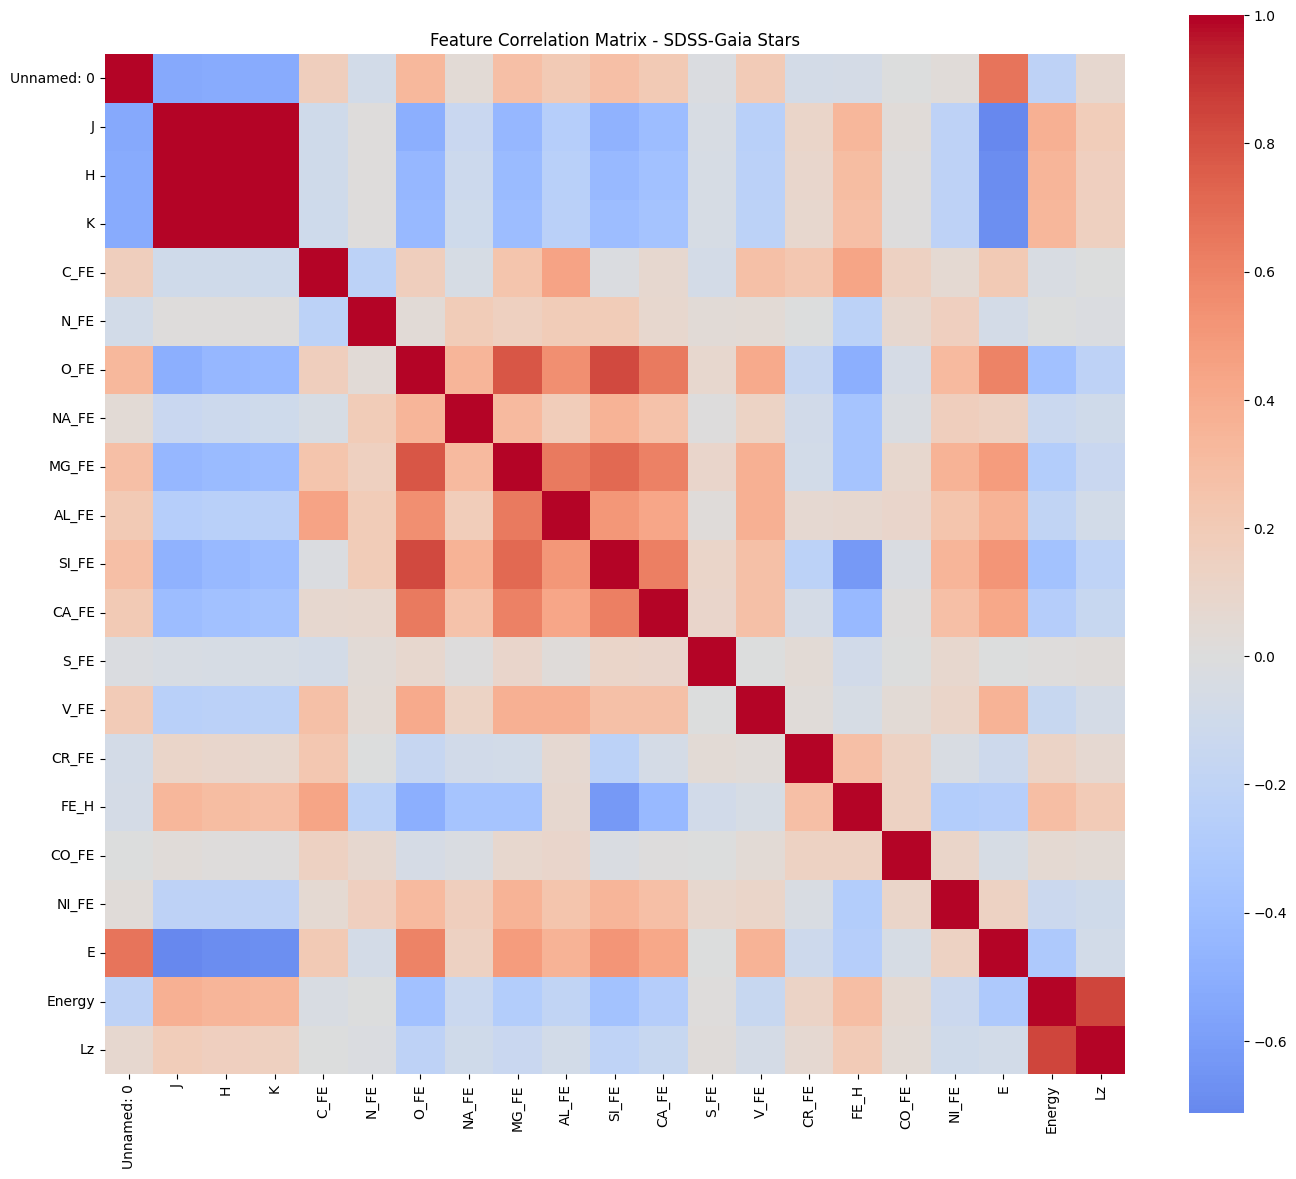


Highly correlated feature pairs (|corr| > 0.8):
H <-> K: 0.9986
J <-> H: 0.9951
J <-> K: 0.9910
Energy <-> Lz: 0.8401
O_FE <-> SI_FE: 0.8288


In [2]:
# Check for missing values
print(f'Missing values:\n{clustering_data.isnull().sum()}')

# Compute correlation matrix
corr_matrix = clustering_data.corr()
print(f'\nCorrelation matrix shape: {corr_matrix.shape}')

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix - SDSS-Gaia Stars')
plt.tight_layout()
plt.show()

# Identify highly correlated features (|corr| > 0.8)
corr_threshold = 0.8
corr_abs = corr_matrix.abs()
adj = corr_abs > corr_threshold
np.fill_diagonal(adj.values, False)

correlated_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if adj.iloc[i, j]:
            correlated_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f'\nHighly correlated feature pairs (|corr| > {corr_threshold}):')
for feat1, feat2, corr_val in sorted(correlated_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f'{feat1} <-> {feat2}: {corr_val:.4f}')

In [3]:
# Select best 6 features using variance and correlation-based selection
# Strategy: pick features with high variance and low redundancy

# Compute variance for each feature
variances = clustering_data.var()
variances_sorted = variances.sort_values(ascending=False)
print(f'Feature variances (top 15):')
print(variances_sorted.head(15))

# Select top features iteratively: start with highest variance, add features with lowest correlation to already selected
selected_features = [variances_sorted.index[0]]  # Start with highest variance
remaining_features = variances_sorted.index[1:].tolist()

while len(selected_features) < 6 and remaining_features:
    # Find feature with lowest average correlation to selected features
    best_feature = None
    best_avg_corr = float('inf')
    for feat in remaining_features:
        avg_corr = abs(corr_matrix.loc[feat, selected_features]).mean()
        if avg_corr < best_avg_corr:
            best_avg_corr = avg_corr
            best_feature = feat
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

print(f'\nSelected features for clustering (6):')
print(selected_features)
print(f'\nAverage correlations:')
for feat in selected_features:
    print(f'{feat}: {abs(corr_matrix.loc[feat, selected_features]).mean():.4f}')

Feature variances (top 15):
Energy        3.900940e+09
Lz            1.085920e+07
Unnamed: 0    2.950704e+06
J             1.250752e+00
H             1.165388e+00
K             1.155551e+00
V_FE          1.128677e-01
NA_FE         1.127459e-01
FE_H          9.134656e-02
S_FE          7.731425e-02
CR_FE         5.316132e-02
CO_FE         4.295841e-02
E             3.950006e-02
N_FE          2.386939e-02
C_FE          2.256855e-02
dtype: float64

Selected features for clustering (6):
['Energy', 'N_FE', 'S_FE', 'CO_FE', 'V_FE', 'CR_FE']

Average correlations:
Energy: 0.2269
N_FE: 0.1941
S_FE: 0.1828
CO_FE: 0.2207
V_FE: 0.2129
CR_FE: 0.2215


In [4]:
# Prepare data for clustering
X = clustering_data[selected_features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

print(f'Scaled data shape: {X_scaled_df.shape}')
print(f'\nScaled data statistics:')
print(X_scaled_df.describe())

Scaled data shape: (5950, 6)

Scaled data statistics:
             Energy          N_FE          S_FE         CO_FE          V_FE  \
count  5.950000e+03  5.950000e+03  5.950000e+03  5.950000e+03  5.950000e+03   
mean   3.821406e-17  4.776758e-17 -7.165137e-17  2.627217e-17  1.241957e-16   
std    1.000084e+00  1.000084e+00  1.000084e+00  1.000084e+00  1.000084e+00   
min   -1.669879e+00 -4.254861e+00 -3.941259e+00 -8.476995e+00 -3.580371e+00   
25%   -4.990490e-01 -4.424240e-01 -5.088900e-01 -2.703386e-01 -3.883485e-01   
50%    4.477233e-02 -7.482340e-02  6.588402e-02  1.325752e-01  9.572586e-02   
75%    3.826945e-01  3.379051e-01  6.311446e-01  4.608915e-01  3.841492e-01   
max    5.671040e+01  1.197650e+01  2.296606e+00  6.832393e+00  5.292253e+00   

              CR_FE  
count  5.950000e+03  
mean   1.910703e-17  
std    1.000084e+00  
min   -5.393391e+00  
25%   -2.351598e-01  
50%    2.376050e-01  
75%    5.306786e-01  
max    5.322034e+00  


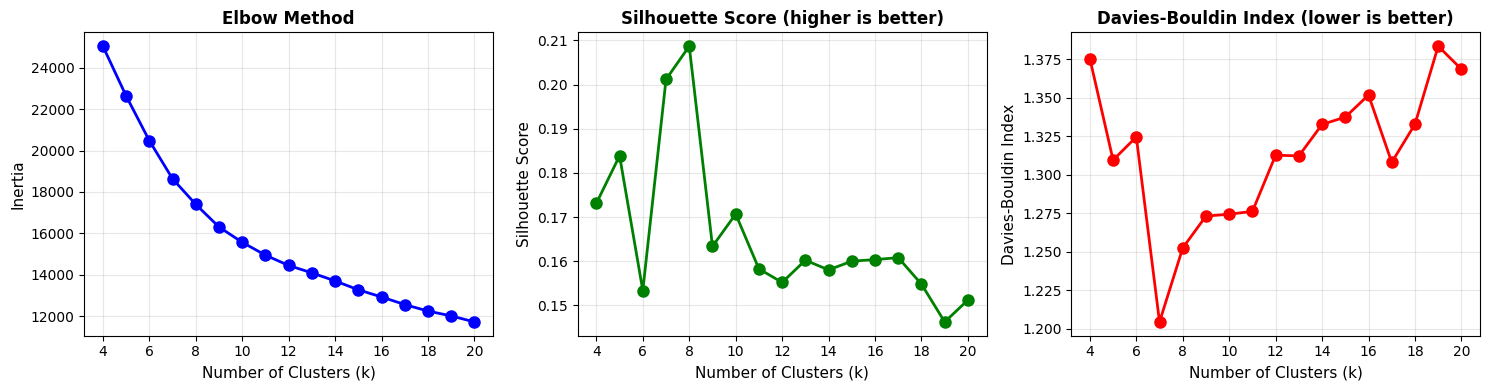


Optimal number of clusters (by Silhouette): 8
Silhouette score: 0.2087


In [5]:
# Determine optimal number of clusters using elbow method and silhouette score
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(4, 21)  # Test 4 to 20 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score (higher is better)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[2].set_title('Davies-Bouldin Index (lower is better)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'\nOptimal number of clusters (by Silhouette): {optimal_k}')
print(f'Silhouette score: {silhouette_scores[optimal_k - 4]:.4f}')

In [6]:
# Train final KMeans model with optimal k
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
cluster_labels = final_kmeans.fit_predict(X_scaled)

print(f'Final model with k={optimal_k}')
print(f'Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}')
print(f'Davies-Bouldin index: {davies_bouldin_score(X_scaled, cluster_labels):.4f}')
print(f'\nCluster distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f'Cluster {label}: {count} samples ({100*count/len(cluster_labels):.1f}%)')

Final model with k=8
Silhouette score: 0.2083
Davies-Bouldin index: 1.2511

Cluster distribution:
Cluster 0: 259 samples (4.4%)
Cluster 1: 791 samples (13.3%)
Cluster 2: 502 samples (8.4%)
Cluster 3: 2762 samples (46.4%)
Cluster 4: 1043 samples (17.5%)
Cluster 5: 259 samples (4.4%)
Cluster 6: 1 samples (0.0%)
Cluster 7: 333 samples (5.6%)


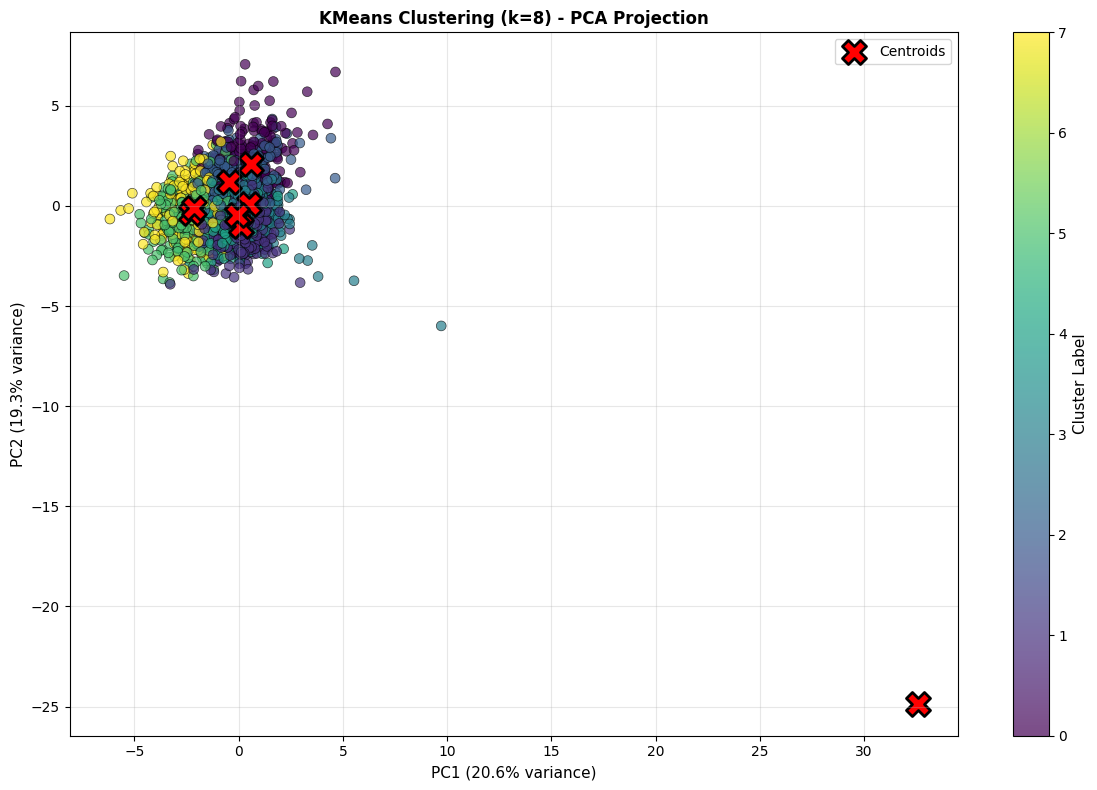

In [7]:
# Visualize clusters using PCA for 2D projection
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.scatter(pca.transform(final_kmeans.cluster_centers_)[:, 0], 
           pca.transform(final_kmeans.cluster_centers_)[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
plt.title(f'KMeans Clustering (k={optimal_k}) - PCA Projection', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label', fontsize=11)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Export results in submission format
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path('./Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
solution_name = 'KMeans'
name = 'BenjaminSiddique'
predictions_filename = f'Clustering_{name}_{solution_name}.csv'
predictions_filepath = output_dir / predictions_filename

with open(predictions_filepath, 'w') as f:
    for idx, label in enumerate(cluster_labels):
        f.write(f'{idx},{int(label)}\n')

print(f'Predictions exported to {predictions_filepath}')

# Export variable list
varlist_filename = f'Clustering_{name}_{solution_name}_VariableList.csv'
varlist_filepath = output_dir / varlist_filename

with open(varlist_filepath, 'w') as f:
    for var in selected_features:
        f.write(f'{var}\n')

print(f'Variable list exported to {varlist_filepath}')

Predictions exported to Output\Clustering_BenjaminSiddique_KMeans.csv
Variable list exported to Output\Clustering_BenjaminSiddique_KMeans_VariableList.csv


In [9]:
# Run SubmissionChecker if available
import sys, subprocess

checker_path = Path('../../SubmissionChecker.py')
if checker_path.exists():
    returncode = subprocess.run([sys.executable, str(checker_path.resolve()), str(output_dir.resolve())])
    if returncode.returncode == 0:
        print('\n✓ Submission files passed validation checks.')
    else:
        print('\n✗ Submission files failed validation checks. Please review the output above for details.')
else:
    print('SubmissionChecker.py not found at expected location')

SubmissionChecker.py not found at expected location
